# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%
c:\Users\Alex's-Laptop\Documents\GitHub\CIFAR-10-Image-Classifier\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Data Format & Batch Creation

In [6]:
from model.model import Model
image, label = training_data[0]
print(image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

from torch.utils.data import DataLoader

train_loader = DataLoader(training_data, batch_size=64, shuffle=True)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([64, 3, 32, 32])
labels: [batch_size]
torch.Size([64])


# Example images

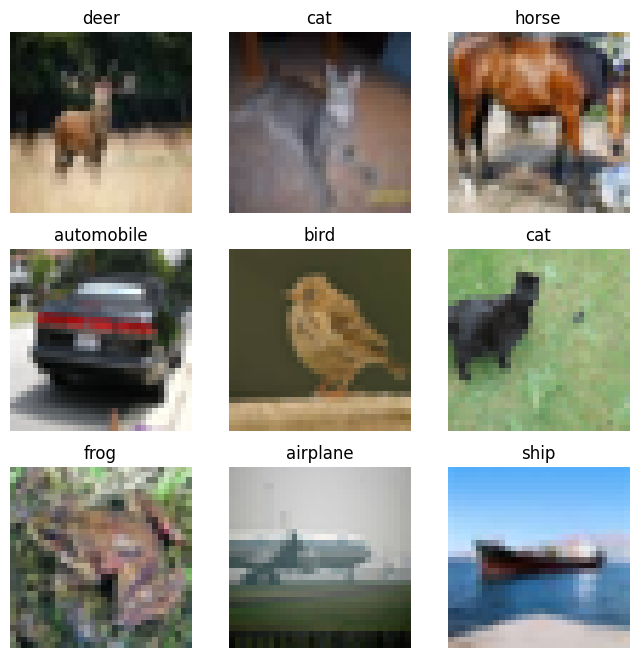

In [ ]:
import torch
import matplotlib.pyplot as plt

labels_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), (1,)).item()
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")

    # Convert from [C, H, W] → [H, W, C]
    plt.imshow(img.permute(1, 2, 0))

plt.show()

## Create model (Pytorch Implementation)

### Layer Creation

In [ ]:
# Convolutional Layer
import torch.nn as nn
"""
Input: Normalized X matrix

# Conv2D Parameters
in_channels (3): 1 for grayscale, 3 for RGB, ...
out_channels: number of our choosing - each filter learns something different
    ex: edges, corners, textures, shapes, ...

kernel_size (3x3): Imagine 3x3 grid sliding across all pixels

# Other parameters can be included but optional
"""
layer1_conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3,3))


In [ ]:
# ReLU activation layer
"""
input: previous layers Z
No parameters required
"""
layer2_relu = nn.ReLU()


'\ninput: Previous layer \n'

In [ ]:
# Flatten Layer
"""
input: Torch tensor (Batch size, All output features of previous layer)
ex usage
t = torch.tensor([[[1, 2],
                   [3, 4]],
                  [[5, 6],
                   [7, 8]]])
torch.flatten(t)
tensor([1, 2, 3, 4, 5, 6, 7, 8])
torch.flatten(t, start_dim=1)
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
"""

layer3_flatten = nn.flatten()

In [ ]:
# Fully-Connected Layer
"""
Input: Flattened Layer

Parameters:
in_features: size of each input sample 
out_features: size of each output sample
- Change depending on layer - if final layer should be the logit for every class
- if final layer we want output of 10 for 10 classes
bias: True/False to include or exclude bias
"""
# Size: H*W*F
layer4_FC = nn.Linear(in_features=32*32*32)


In [ ]:
from typing import OrderedDict

# https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html#torch.nn.Sequential
# Use sequential to perform operations layer by layer
model = nn.Sequential(
    OrderedDict(
        [
            # ("conv1", nn.Conv2d(1, 20, 5)),
            # ("relu1", nn.ReLU()),
            # ("conv2", nn.Conv2d(20, 64, 5)),
            # ("relu2", nn.ReLU()),
        ]
    )
)

"""
Runs the forward pass.

def forward(self, input):
    for module in self:
        input = module(input)
    return input

"""

In [ ]:
from model.model import Model
from model.layers import Linear, Flatten, Softmax

from torch.utils.data import DataLoader

FlattenLayer = Flatten()
LinearLayer = Linear()
SoftMaxLayer = Softmax()

# example layers (strings just for demonstration)
layers = [FlattenLayer, LinearLayer, SoftMaxLayer]
for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)
    break

model = Model(layers)

model.train(train_loader, epochs=10)

images: [batch_size, channels, height, width]
torch.Size([64, 3, 32, 32])
labels: [batch_size]
torch.Size([64])
Now training with layers ['Conv2d', 'ReLU', 'Flatten', 'Linear', 'Softmax']
Using <torch.utils.data.dataloader.DataLoader object at 0x00000263C1A1E060>
